# Quantitative Work-Life Healthcare Analysis (n=50)

This notebook analyzes work-life and burnout indicators from `Quant_WorkLife_Healthcare_50.csv`.

**Goals**
- Profile the dataset and validate data quality
- Explore workload, sleep, satisfaction, and burnout relationships
- Compare burnout patterns across healthcare professions

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

candidate_paths = [
    Path('Quant_WorkLife_Healthcare_50.csv'),
    Path(r'c:\\Users\\josep\\Downloads\\Quant_WorkLife_Healthcare_50.csv'),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('Could not find Quant_WorkLife_Healthcare_50.csv in workspace or Downloads.')

print(f'Using file: {csv_path.resolve()}')

Using file: C:\Users\josep\Downloads\Quant_WorkLife_Healthcare_50.csv


In [9]:
df = pd.read_csv(csv_path)

numeric_cols = [
    'Years_Experience',
    'Weekly_Hours',
    'Sleep_Hours',
    'Job_Satisfaction_1to10',
    'Burnout_Score_0to54'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
display(df.head())

Rows: 50, Columns: 7


,ID,Profession,Years_Experience,Weekly_Hours,Sleep_Hours,Job_Satisfaction_1to10,Burnout_Score_0to54
0,1,Nurse,0.0,47.2,8.45,4.8,17
1,2,Physician,16.9,51.8,7.88,5.6,20
2,3,Physician,10.2,54.9,7.47,8.7,21
3,4,Physician,13.1,57.2,7.69,8.1,23
4,5,Physician,4.6,60.9,8.54,5.7,22


In [10]:
summary = df[numeric_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
missing = df.isna().sum().sort_values(ascending=False)

print('Descriptive statistics:')
display(summary.round(2))

print('Missing values by column:')
display(missing.to_frame('missing_count'))

Descriptive statistics:


,mean,std,min,25%,50%,75%,max
Years_Experience,8.73,5.45,0.00,4.75,9.40,12.82,22.0
Weekly_Hours,42.54,8.28,28.00,37.60,40.90,48.10,60.9
Sleep_Hours,8.01,0.61,6.65,7.68,7.99,8.40,9.5
Job_Satisfaction_1to10,7.44,1.40,3.40,6.50,7.50,8.38,10.0
Burnout_Score_0to54,10.56,7.97,0.00,4.25,10.00,15.75,26.0


Missing values by column:


,missing_count
ID,0
Profession,0
Years_Experience,0
Weekly_Hours,0
Sleep_Hours,0
Job_Satisfaction_1to10,0
Burnout_Score_0to54,0


In [11]:
profession_counts = df['Profession'].value_counts().rename_axis('Profession').to_frame('Count')
burnout_by_profession = (
    df.groupby('Profession')['Burnout_Score_0to54']
      .agg(mean='mean', median='median', count='count')
      .reset_index()
)

print('Profession distribution:')
display(profession_counts)

print('Burnout by profession:')
display(burnout_by_profession.round(2).sort_values('mean', ascending=False))

Profession distribution:


,Count
Profession,
Therapist,13
Nurse,10
Physician,7
Admin,6
Paramedic,6
Respiratory Therapist,5
Psychologist,3


Burnout by profession:


,Profession,mean,median,count
3,Physician,19.86,22.0,7
5,Respiratory Therapist,12.00,9.0,5
2,Paramedic,11.33,10.0,6
1,Nurse,10.90,11.5,10
0,Admin,9.33,11.5,6
6,Therapist,6.23,7.0,13
4,Psychologist,5.00,1.0,3


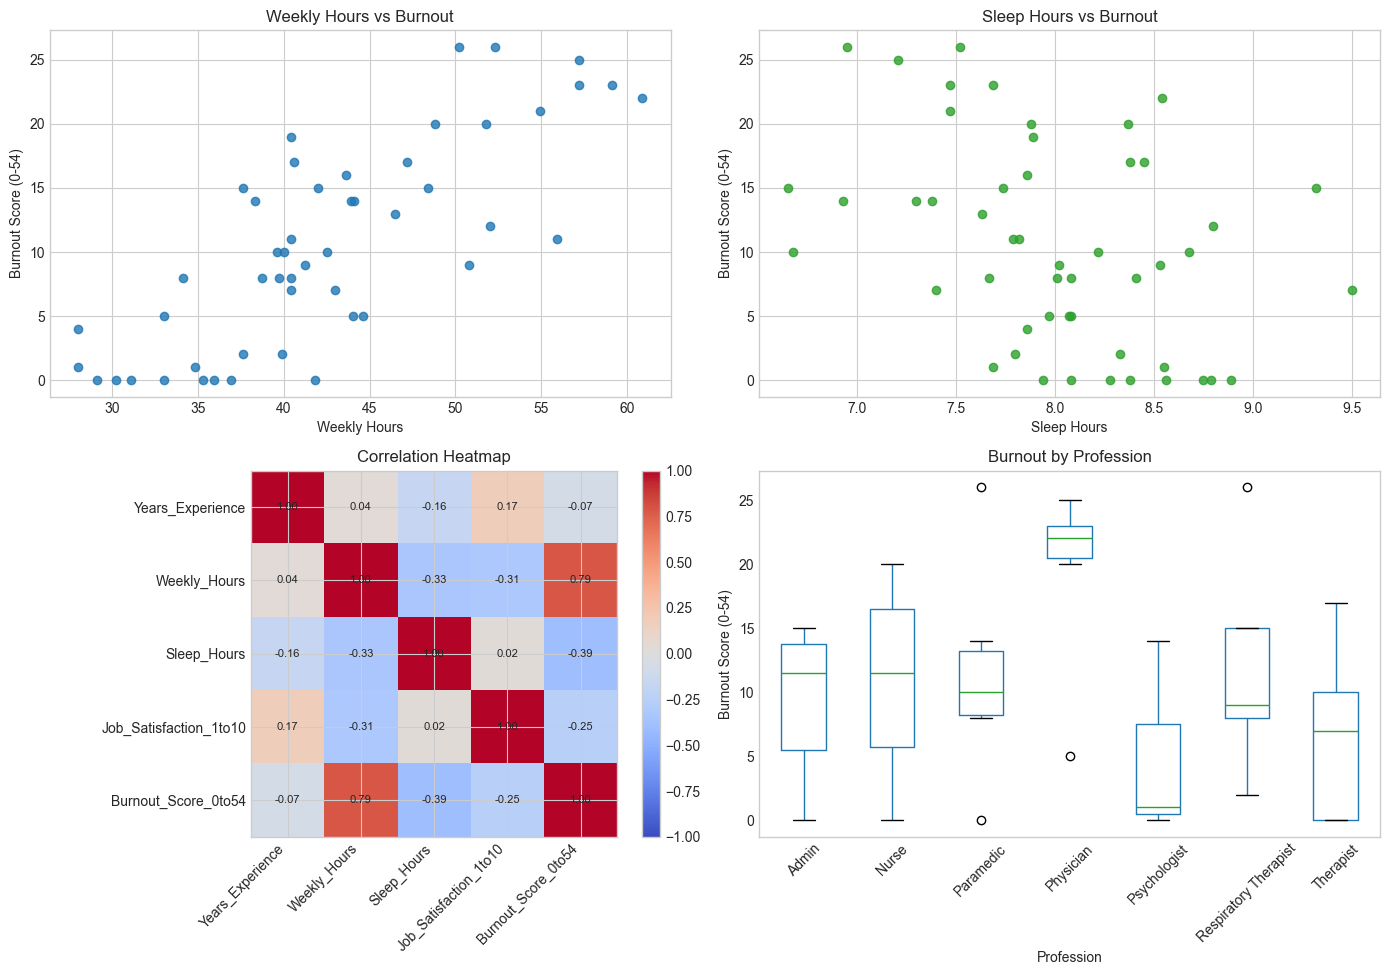

,Years_Experience,Weekly_Hours,Sleep_Hours,Job_Satisfaction_1to10,Burnout_Score_0to54
Years_Experience,1.00,0.04,-0.16,0.17,-0.07
Weekly_Hours,0.04,1.00,-0.33,-0.31,0.79
Sleep_Hours,-0.16,-0.33,1.00,0.02,-0.39
Job_Satisfaction_1to10,0.17,-0.31,0.02,1.00,-0.25
Burnout_Score_0to54,-0.07,0.79,-0.39,-0.25,1.00


In [12]:
corr = df[numeric_cols].corr(numeric_only=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(df['Weekly_Hours'], df['Burnout_Score_0to54'], alpha=0.8)
axes[0, 0].set_title('Weekly Hours vs Burnout')
axes[0, 0].set_xlabel('Weekly Hours')
axes[0, 0].set_ylabel('Burnout Score (0-54)')

axes[0, 1].scatter(df['Sleep_Hours'], df['Burnout_Score_0to54'], alpha=0.8, color='tab:green')
axes[0, 1].set_title('Sleep Hours vs Burnout')
axes[0, 1].set_xlabel('Sleep Hours')
axes[0, 1].set_ylabel('Burnout Score (0-54)')

im = axes[1, 0].imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
axes[1, 0].set_xticks(range(len(corr.columns)))
axes[1, 0].set_xticklabels(corr.columns, rotation=45, ha='right')
axes[1, 0].set_yticks(range(len(corr.index)))
axes[1, 0].set_yticklabels(corr.index)
axes[1, 0].set_title('Correlation Heatmap')
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        axes[1, 0].text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

df.boxplot(column='Burnout_Score_0to54', by='Profession', ax=axes[1, 1], grid=False)
axes[1, 1].set_title('Burnout by Profession')
axes[1, 1].set_xlabel('Profession')
axes[1, 1].set_ylabel('Burnout Score (0-54)')
axes[1, 1].tick_params(axis='x', rotation=45)
plt.suptitle('')

plt.tight_layout()
plt.show()

display(corr.round(2))

In [13]:
corr_weekly_burnout = df['Weekly_Hours'].corr(df['Burnout_Score_0to54'])
corr_sleep_burnout = df['Sleep_Hours'].corr(df['Burnout_Score_0to54'])
corr_sat_burnout = df['Job_Satisfaction_1to10'].corr(df['Burnout_Score_0to54'])

top_burnout = (
    df.groupby('Profession')['Burnout_Score_0to54']
      .mean()
      .sort_values(ascending=False)
      .head(3)
)

print('Key findings (sample-level, exploratory):')
print(f'- Weekly hours vs burnout correlation: {corr_weekly_burnout:.2f}')
print(f'- Sleep hours vs burnout correlation: {corr_sleep_burnout:.2f}')
print(f'- Job satisfaction vs burnout correlation: {corr_sat_burnout:.2f}')
print('\nTop 3 professions by mean burnout score:')
display(top_burnout.round(2).to_frame('Mean_Burnout_Score'))

Key findings (sample-level, exploratory):
- Weekly hours vs burnout correlation: 0.79
- Sleep hours vs burnout correlation: -0.39
- Job satisfaction vs burnout correlation: -0.25

Top 3 professions by mean burnout score:


,Mean_Burnout_Score
Profession,
Physician,19.86
Respiratory Therapist,12.00
Paramedic,11.33


## Interpretation Notes

- This is a small dataset (`n=50`), so results are exploratory and not necessarily generalizable.
- Correlations indicate association, not causation.
- Consider follow-up modeling with larger samples and additional covariates (e.g., shift type, setting acuity, staffing ratio).

## Plain-English Results Summary

Here is what this dataset suggests in simple terms:

- **Longer work weeks are linked with more burnout.** In this sample, people who worked more hours per week generally had higher burnout scores.
- **More sleep is linked with less burnout.** People who reported more sleep tended to have lower burnout.
- **Higher job satisfaction is linked with lower burnout.** This relationship is weaker than work hours, but it still trends in the expected direction.
- **Work hours appear to be the strongest signal here.** The relationship between weekly hours and burnout is much stronger than the other factors in this dataset.
- **Burnout differs by profession in this sample.** Physicians had the highest average burnout score, while therapists and psychologists were lower on average.

### Important caveats

- This is a small sample (`n=50`), so these results should be treated as exploratory.
- These are associations, not proof of cause-and-effect.
- Profession groups have different sample sizes, which can affect comparisons.